# Backtest 005e — TTM Breakout + GKYZ Volatility Risk Filter (VNINDEX)

Fork of **backtest_005b** that replaces the SMF Cloud regime gate with a
**Garman-Klass-Yang-Zhang (GKYZ) volatility hysteresis filter** on **VNINDEX**.

## Regime logic

| Condition | State |
|-----------|-------|
| GKYZ (VNINDEX, normalised) crosses **above 0.8** | **risk-on** (high-vol sticky state) |
| GKYZ stays in `[0.2, 0.8]` | hold previous state |
| GKYZ crosses **below 0.2** | **risk-off** (low-vol sticky state) |

**GKYZ position sizing (by entry variant)**
- **v1 / v2 (trend-following)** — shrink in turbulent markets: **risk-on → ½**, **risk-off → full**.
- **v3 (mean-reversion)** — lean in when dispersion is high: **risk-on → full**, **risk-off → ½**.

This is a Schmitt-trigger (hysteresis) so the state is sticky — no whipsawing
on every bar. The TTM Breakout entry conditions (squeeze, momentum, KAMA slope)
are unchanged from 005; only the **percent-of-equity** at entry changes with the
GKYZ regime and the strategy variant.


In [1]:
import warnings
warnings.filterwarnings('ignore')

import os, sys, pathlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numba as nb
import vectorbt as vbt
import optuna
import talib
optuna.logging.set_verbosity(optuna.logging.WARNING)

sys.path.insert(0, str(pathlib.Path('..').resolve()))
from backend.app.services.indicators.trailing_sl import atr_trailing_nb
from backend.app.services.indicators.wiliams_vix_fix import williams_vix_fix_indicator
from backend.app.services.indicators.gkyz_volatility import calculate_gkyz_volatility

plt.style.use('dark_background')
print('imports ok')

imports ok


## 1. Load Data

In [2]:
REMOTE_HOST = 'http://192.168.1.30:9000'

def load_stock_data() -> pd.DataFrame:
    from deltalake import DeltaTable
    storage_options = {
        'AWS_ACCESS_KEY_ID':          'CzOwnLkEDXQy951AOqes',
        'AWS_SECRET_ACCESS_KEY':      'fdRe91TOtqTl0icUkZLsUnWvZa90aZ5qG5rVEf7S',
        'AWS_ENDPOINT_URL':           REMOTE_HOST,
        'AWS_ALLOW_HTTP':             'true',
        'AWS_EC2_METADATA_DISABLED':  'true',
        'AWS_REGION':                 'us-east-1',
        'aws_conditional_put':        'etag',
    }
    watchlist_df      = pd.read_csv('../backend/models/watchlist.csv')
    watchlist_symbols = watchlist_df.iloc[:, 0].values
    start_date        = pd.Timestamp.now() - pd.DateOffset(years=10)

    dt = DeltaTable('s3://delta-table-storage/stocks', storage_options=storage_options)
    raw = dt.to_pandas(
        filters=[('date', '>=', start_date), ('symbol', 'in', watchlist_symbols)],
        columns=['symbol', 'date', 'close', 'open', 'high', 'low', 'volume'],
    )
    raw = raw.drop_duplicates(subset=['date', 'symbol'], keep='last')
    raw = raw.set_index(['date', 'symbol'])
    stocks = raw.unstack(level=1).bfill().ffill()
    print('Loaded from DeltaLake')
    return stocks


local_file = 'stocks_data_latest.h5'
store_key  = 'stocks'

if os.path.exists(local_file):
    print(f'Loading from local HDF5: {local_file}')
    with pd.HDFStore(local_file, mode='r') as store:
        df_raw = store[store_key]
else:
    print('HDF5 not found — loading from DeltaLake ...')
    df_raw = load_stock_data()
    with pd.HDFStore(local_file, mode='w') as store:
        store.put(store_key, df_raw)

watchlist_df      = pd.read_csv('../backend/models/watchlist.csv')
watchlist_symbols = watchlist_df.iloc[:, 0].values
df_raw = df_raw.loc[:, df_raw.columns.get_level_values('symbol').isin(watchlist_symbols)]

open_   = df_raw['open']
high    = df_raw['high']
low     = df_raw['low']
close   = df_raw['close']
volume  = df_raw['volume']

print(f'Shape: {close.shape}  |  {close.index[0]} -> {close.index[-1]}')
close.tail(3)

Loading from local HDF5: stocks_data_latest.h5
Shape: (2499, 197)  |  2016-05-06 00:00:00 -> 2026-05-05 00:00:00


symbol,AAA,ABB,ACB,ACV,ADS,AGG,AGR,ANV,APH,ASM,...,VNINDEX,VNM,VOS,VPB,VPG,VPI,VRE,VSC,VTP,YEG
date,,,,,,,,,,,,,,,,,,,,,
2026-04-29,7.31,14.9,23.5,44.0,9.09,12.60,14.50,23.90,5.83,5.63,...,1854.70,60.9,12.60,26.50,3.49,61.4,32.3,21.35,68.0,10.00
2026-05-04,7.48,15.0,23.1,44.0,9.02,12.50,14.55,23.95,5.95,6.02,...,1853.19,60.9,12.55,26.95,3.48,61.3,33.7,21.60,68.0,10.00
2026-05-05,7.37,14.9,22.6,44.8,9.02,12.35,14.40,23.45,5.84,6.27,...,1873.31,61.1,12.45,28.00,3.50,62.5,35.2,21.45,65.9,9.96


## 2. TTM Breakout Helpers

In [3]:
@nb.njit
def shift_2d(arr, num, fill_value=np.nan):
    result = np.empty_like(arr)
    n = arr.shape[0]
    if num > 0:
        result[:num, :] = fill_value
        result[num:, :] = arr[:n - num, :]
    elif num < 0:
        result[n + num:, :] = fill_value
        result[:n + num, :] = arr[-num:, :]
    else:
        result[:, :] = arr
    return result


@nb.njit
def count_consecutive_neg_2d(arr):
    n, m  = arr.shape
    out   = np.zeros((n, m), dtype=np.int64)
    for j in range(m):
        count = 0
        for i in range(n):
            if arr[i, j] < 0:
                count += 1
                out[i, j] = count
            else:
                count = 0
    return out


@nb.njit(cache=True)
def kama_2d(prices_np, period=10, fast=2, slow=30):
    n, m    = prices_np.shape
    out     = np.full((n, m), np.nan)
    fast_sc = 2.0 / (fast + 1)
    slow_sc = 2.0 / (slow + 1)
    for j in range(m):
        kama = prices_np[period - 1, j]
        out[period - 1, j] = kama
        for i in range(period, n):
            direction  = abs(prices_np[i, j] - prices_np[i - period, j])
            volatility = 0.0
            for k in range(1, period + 1):
                volatility += abs(prices_np[i - k + 1, j] - prices_np[i - k, j])
            er = direction / volatility if volatility != 0.0 else 0.0
            sc = (er * (fast_sc - slow_sc) + slow_sc) ** 2
            kama = kama + sc * (prices_np[i, j] - kama)
            out[i, j] = kama
    return out


@nb.njit(cache=True)
def slope_flat_2d(kama_np, slope_window, flat_threshold_pct):
    n, m = kama_np.shape
    out  = np.zeros((n, m), dtype=nb.boolean)
    for j in range(m):
        for i in range(slope_window, n):
            prev = kama_np[i - slope_window, j]
            if prev != 0.0 and not np.isnan(prev) and not np.isnan(kama_np[i, j]):
                slope_pct = abs((kama_np[i, j] - prev) / prev * 100.0)
                out[i, j] = slope_pct < flat_threshold_pct
    return out


print('Numba helpers compiled')

Numba helpers compiled


In [4]:
def compute_signals(
    close, high, low,
    bb_window=16, bb_multiplier=1.0, bb_matype=0,
    kc_window=40, kc_multiplier=1.2, kc_atr_period=10,
    donichan_window=12, osc_smoothing_period=10,
    entry_version='v3', consecutive_neg_threshold=7,
    william_vix_period=20,
    use_kama_slope=True, kama_period=10, kama_fast=2, kama_slow=30,
    kama_slope_win=5, flat_threshold_pct=1.0,
):
    BB   = vbt.IndicatorFactory.from_talib('BBANDS')
    ATR  = vbt.IndicatorFactory.from_talib('ATR')
    EMA  = vbt.IndicatorFactory.from_talib('EMA')
    SMA  = vbt.IndicatorFactory.from_talib('SMA')
    MAX  = vbt.IndicatorFactory.from_talib('MAX')
    LREG = vbt.IndicatorFactory.from_talib('LINEARREG')

    bb  = BB.run(close, timeperiod=bb_window,
                 nbdevup=bb_multiplier, nbdevdn=bb_multiplier, matype=bb_matype)
    atr = ATR.run(high, low, close, timeperiod=kc_atr_period)
    ema = EMA.run(close, timeperiod=kc_window)

    bb_upper_np  = bb.upperband.to_numpy()
    bb_lower_np  = bb.lowerband.to_numpy()
    ema_np       = ema.real.to_numpy()
    atr_np       = atr.real.to_numpy()
    kc_upper_np  = ema_np + kc_multiplier * atr_np
    kc_lower_np  = ema_np - kc_multiplier * atr_np

    hh  = MAX.run(high, timeperiod=donichan_window).real.to_numpy()
    ll  = MAX.run(low,  timeperiod=donichan_window).real.to_numpy()
    sma = SMA.run(close, timeperiod=donichan_window).real.to_numpy()
    close_np  = close.to_numpy()
    histogram = close_np - ((hh + ll) / 2 + sma) / 2
    ttms_np   = LREG.run(
        pd.DataFrame(histogram, index=close.index, columns=close.columns),
        timeperiod=osc_smoothing_period,
    ).real.to_numpy()

    _, _, _, wvf_signal = williams_vix_fix_indicator(
        close, high, low,
        period=william_vix_period, mult=bb_multiplier,
        bbl=bb_window, lb=20, ph=0.85, ltLB=33, mtLB=10, strength_str=1,
    )
    wvf_np = wvf_signal if isinstance(wvf_signal, np.ndarray) else wvf_signal.to_numpy()

    if use_kama_slope:
        kama_np = kama_2d(close_np.astype(np.float64), kama_period, kama_fast, kama_slow)
        flat_np = slope_flat_2d(kama_np, kama_slope_win, flat_threshold_pct)
    else:
        flat_np = np.ones_like(close_np, dtype=np.bool_)

    if entry_version == 'v1':
        sqz_on_np  = (bb_upper_np < kc_upper_np) & (bb_lower_np > kc_lower_np)
        sqz_off_np = (bb_upper_np > kc_upper_np) & (bb_lower_np < kc_lower_np)
        no_sqz_np  = (~sqz_on_np) & (~sqz_off_np)
        entries_np = no_sqz_np & (ttms_np > 0) & flat_np
    elif entry_version == 'v2':
        sqz_on_np  = (bb_upper_np < kc_upper_np) & (bb_lower_np > kc_lower_np)
        sqz_off_np = (bb_upper_np > kc_upper_np) & (bb_lower_np < kc_lower_np)
        no_sqz_np  = (~sqz_on_np) & (~sqz_off_np)
        ttms_1 = shift_2d(ttms_np, 1); ttms_2 = shift_2d(ttms_np, 2); ttms_3 = shift_2d(ttms_np, 3)
        crossed_now  = (ttms_1 < 0) & (ttms_np > 0)
        crossed_1ago = (ttms_2 < 0) & (ttms_1  > 0)
        crossed_2ago = (ttms_3 < 0) & (ttms_2  > 0)
        cond_2  = (ttms_np > ttms_1) & crossed_1ago
        cond_3  = (ttms_np > ttms_2) & crossed_2ago
        entries_np = no_sqz_np & (crossed_now | cond_2 | cond_3) & flat_np
    else:  # v3
        squeeze_diff_np = bb_upper_np - kc_upper_np
        consec_neg      = count_consecutive_neg_2d(ttms_np)
        entry_1 = (
            (shift_2d(squeeze_diff_np, 1) < 0) & (squeeze_diff_np > 0)
            & (ttms_np > 0) & flat_np
        )
        entry_2 = (
            (shift_2d(squeeze_diff_np, 1) < 0) & (squeeze_diff_np > 0)
            & (consec_neg > consecutive_neg_threshold)
        )
        entries_np = entry_1 | entry_2 | wvf_np

    return pd.DataFrame(entries_np, index=close.index, columns=close.columns)


def compute_exits(close, high, low, atr_multiplier=1.9, atr_period=10, low_stop_lookback=5):
    atr_raw = vbt.IndicatorFactory.from_talib('ATR').run(
        high, low, close, timeperiod=atr_period
    )
    ATRTrailing = vbt.IndicatorFactory(
        input_names=['close', 'atr'], param_names=['atr_multiplier'],
        output_names=['atr_trailing'],
    ).from_apply_func(atr_trailing_nb)
    atr_sl   = ATRTrailing.run(close, atr_raw.real, atr_multiplier=atr_multiplier)
    exits_df = close.vbt.crossed_below(atr_sl.atr_trailing)
    MIN        = vbt.IndicatorFactory.from_talib('MIN')
    lowest_low = MIN.run(low, timeperiod=low_stop_lookback).real
    sl_stop_df = ((close - lowest_low) / close).clip(lower=0)
    return exits_df, sl_stop_df


print('Signal functions defined')

Signal functions defined


## 3. GKYZ Volatility Risk Regime (VNINDEX)

Compute normalised GKYZ volatility for **VNINDEX** and derive a hysteresis-based
binary risk-on / risk-off state.

```
GKYZ > 0.8  ──►  risk_on = True   (high vol)
GKYZ < 0.2  ──►  risk_on = False  (low vol)
otherwise   ──►  hold previous state
```
**Sizing map:** trend (v1, v2) uses `GKYZ_SIZE_TREND` — ½ stake when risk-on, full when risk-off. Mean-reversion (v3) uses `GKYZ_SIZE_MR` — full when risk-on, ½ when risk-off.


In [5]:
# ── Defaults — can be overridden in Optuna ────────────────────────────────────
GKYZ_WINDOW = 21
GKYZ_UPPER  = 0.8   # threshold to enter risk-on  (high-vol)
GKYZ_LOWER  = 0.2   # threshold to exit  risk-on  (low-vol)


def compute_gkyz_regime(
    open_s: pd.Series,
    high_s: pd.Series,
    low_s:  pd.Series,
    close_s: pd.Series,
    window: int   = GKYZ_WINDOW,
    upper:  float = GKYZ_UPPER,
    lower:  float = GKYZ_LOWER,
) -> tuple:
    """
    Returns (gkyz_series, risk_on_series) both aligned to close_s.index.

    risk_on = True  → high-vol regime; risk_on = False → low-vol regime.
    Map to fractional size with GKYZ_SIZE_TREND (v1/v2) or GKYZ_SIZE_MR (v3).
    """
    gkyz_arr = calculate_gkyz_volatility(
        open_s.values.astype(np.float64),
        high_s.values.astype(np.float64),
        low_s.values.astype(np.float64),
        close_s.values.astype(np.float64),
        window=window,
        normalize=True,
    )

    n = len(gkyz_arr)
    risk_on = np.zeros(n, dtype=bool)
    state   = False                         # start in risk-off
    for i in range(n):
        v = gkyz_arr[i]
        if np.isnan(v):
            risk_on[i] = state
            continue
        if not state and v > upper:         # cross above → risk-on
            state = True
        elif state and v < lower:           # cross below → risk-off
            state = False
        risk_on[i] = state

    idx = close_s.index
    return pd.Series(gkyz_arr, index=idx, name='gkyz'), \
           pd.Series(risk_on,  index=idx, name='risk_on')


# Compute once on VNINDEX
gkyz_vnindex, risk_on_vnindex = compute_gkyz_regime(
    open_['VNINDEX'], high['VNINDEX'], low['VNINDEX'], close['VNINDEX'],
)

n_risk_on  = risk_on_vnindex.sum()
n_risk_off = (~risk_on_vnindex).sum()
print(f'Risk-on  bars: {n_risk_on}  ({n_risk_on / len(risk_on_vnindex) * 100:.1f}%)')
print(f'Risk-off bars: {n_risk_off} ({n_risk_off / len(risk_on_vnindex) * 100:.1f}%)')

Risk-on  bars: 1148  (45.9%)
Risk-off bars: 1351 (54.1%)


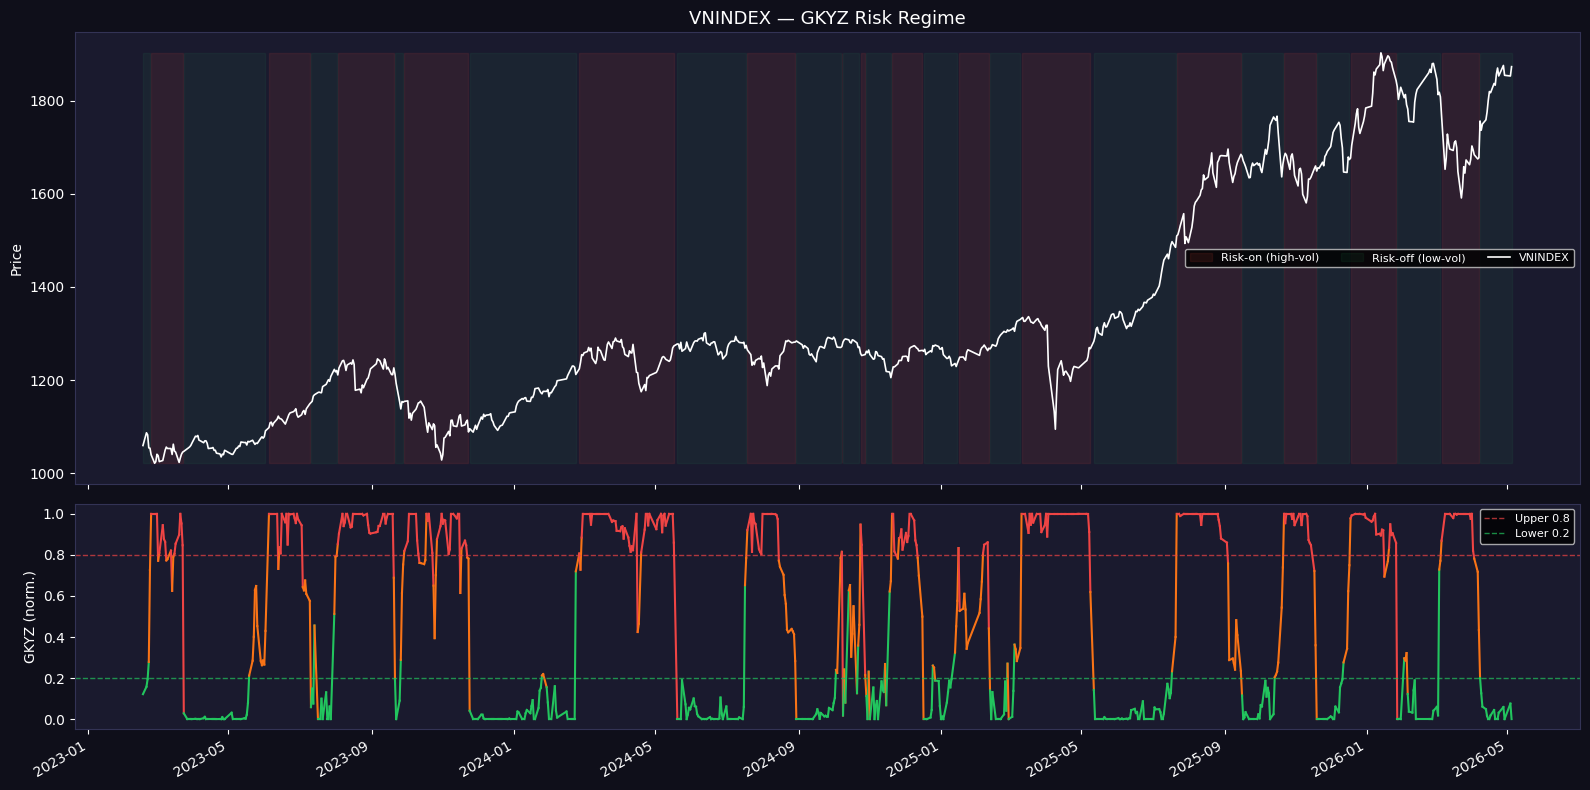

In [6]:
# ── Visualise GKYZ + regime on VNINDEX ───────────────────────────────────────
LOOKBACK = 800
sl_ = slice(-LOOKBACK, None)

dates_v  = close.index[sl_]
c_vn     = close['VNINDEX'].values[sl_]
gkyz_v   = gkyz_vnindex.values[sl_]
ron_v    = risk_on_vnindex.values[sl_]

fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True,
                          gridspec_kw={'height_ratios': [2, 1]})
fig.patch.set_facecolor('#0f0f1a')

ax = axes[0]
ax.set_facecolor('#1a1a2e')
ax.fill_between(dates_v, c_vn.min(), c_vn.max(),
                where=ron_v,  color='#e74c3c', alpha=0.10, label='Risk-on (high-vol)')
ax.fill_between(dates_v, c_vn.min(), c_vn.max(),
                where=~ron_v, color='#2ecc71', alpha=0.06, label='Risk-off (low-vol)')
ax.plot(dates_v, c_vn, color='white', lw=1.2, label='VNINDEX')
ax.set_title('VNINDEX — GKYZ Risk Regime', color='white', fontsize=13)
ax.set_ylabel('Price', color='white')
ax.legend(fontsize=8, ncol=3)
ax.tick_params(colors='white')
for sp in ax.spines.values(): sp.set_edgecolor('#333355')

ax2 = axes[1]
ax2.set_facecolor('#1a1a2e')
colors_g = np.where(gkyz_v > GKYZ_UPPER, '#ef4444',
           np.where(gkyz_v < GKYZ_LOWER, '#22c55e', '#f97316'))
for i in range(len(dates_v) - 1):
    ax2.plot(dates_v[i:i+2], gkyz_v[i:i+2], color=colors_g[i], lw=1.5)
ax2.axhline(GKYZ_UPPER, color='rgba(239,68,68,0.7)'  if False else '#ef4444',
            lw=1.0, ls='--', alpha=0.7, label=f'Upper {GKYZ_UPPER}')
ax2.axhline(GKYZ_LOWER, color='#22c55e', lw=1.0, ls='--', alpha=0.7,
            label=f'Lower {GKYZ_LOWER}')
ax2.set_ylim(-0.05, 1.05)
ax2.set_ylabel('GKYZ (norm.)', color='white')
ax2.legend(fontsize=8)
ax2.tick_params(colors='white')
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
fig.autofmt_xdate(rotation=30)
for sp in ax2.spines.values(): sp.set_edgecolor('#333355')

plt.tight_layout()
plt.show()

## 4. Baseline Run (no filter)
Same TTM v3 default params as **005** — reference point.

In [7]:
print('Computing baseline signals (v3, default params) ...')
entries_base = compute_signals(close, high, low, entry_version='v3')
exits_base, sl_stop_base = compute_exits(close, high, low, atr_multiplier=1.9)
print(f'Entry signals: {entries_base.sum().sum():,}')

pf_base = vbt.Portfolio.from_signals(
    close=close, entries=entries_base, exits=exits_base,
    sl_stop=sl_stop_base, freq='1d', group_by=['symbol'],
)

print('\nBaseline portfolio stats:')
all_metrics = list(pf_base.metrics.keys())
metrics_ok  = [m for m in all_metrics if m not in ('profit_factor', 'expectancy')]
pf_base.stats(metrics=metrics_ok)

Computing baseline signals (v3, default params) ...
Entry signals: 13,537

Baseline portfolio stats:


Start                                 2016-05-06 00:00:00
End                                   2026-05-05 00:00:00
Period                                 2499 days 00:00:00
Start Value                                         100.0
End Value                                       322.49364
Total Return [%]                                222.49364
Benchmark Return [%]                           293.038712
Max Gross Exposure [%]                              100.0
Total Fees Paid                                       0.0
Max Drawdown [%]                                45.623183
Max Drawdown Duration         938 days 15:57:33.807106592
Total Trades                                    55.035533
Total Closed Trades                             54.598985
Total Open Trades                                0.436548
Open Trade PnL                                   7.744468
Win Rate [%]                                    39.367826
Best Trade [%]                                  66.271284
Worst Trade [%

## 5. Baseline + GKYZ Risk Filter

Same **v3** (mean-reversion) defaults as baseline: **risk-on → full position**,
**risk-off → ½ position** (inverse of **v1/v2** trend GKYZ sizing in later sections).

In [8]:
# Trend (v1, v2): high-vol → smaller; mean-reversion (v3): high-vol → larger
GKYZ_SIZE_TREND = dict(risk_on_size=0.5, risk_off_size=1.0)
GKYZ_SIZE_MR    = dict(risk_on_size=1.0, risk_off_size=0.5)


def build_size_matrix(
    risk_on_series: pd.Series,
    columns: pd.Index,
    risk_on_size: float = 0.5,
    risk_off_size: float = 1.0,
) -> pd.DataFrame:
    """VNINDEX hysteresis regime → per-bar size fractions (broadcast to symbols)."""
    col_1d = np.where(risk_on_series.values, risk_on_size, risk_off_size)  # (T,)
    mat = np.tile(col_1d[:, None], (1, len(columns)))                      # (T, N)
    return pd.DataFrame(mat, index=risk_on_series.index, columns=columns)


# Baseline notebook section uses entry_version v3 → mean-reversion sizing
size_base_gkyz = build_size_matrix(risk_on_vnindex, close.columns, **GKYZ_SIZE_MR)

pf_base_gkyz = vbt.Portfolio.from_signals(
    close     = close,
    entries   = entries_base,
    exits     = exits_base,
    sl_stop   = sl_stop_base,
    size      = size_base_gkyz,
    size_type = 'percent',
    freq      = '1d',
    group_by  = ['symbol'],
    cash_sharing = False,
)

sv_bas      = pf_base.sharpe_ratio().replace([np.inf, -np.inf], np.nan).dropna()
sv_bas_gkyz = pf_base_gkyz.sharpe_ratio().replace([np.inf, -np.inf], np.nan).dropna()
print(f'Baseline (no filter) |  Sharpe mean={sv_bas.mean():.3f}  >1: {(sv_bas>1).sum()}/{len(sv_bas)}')
print(f'Baseline + GKYZ gate |  Sharpe mean={sv_bas_gkyz.mean():.3f}  >1: {(sv_bas_gkyz>1).sum()}/{len(sv_bas_gkyz)}')


Baseline (no filter) |  Sharpe mean=0.588  >1: 26/197
Baseline + GKYZ gate |  Sharpe mean=0.587  >1: 26/197


## 6. Optuna Optimisation — GKYZ window + thresholds

TTM params are fixed from the prior optimisation (005b).  
Only GKYZ `window`, `upper` and `lower` thresholds are searched.

Objectives: **(Mean Total Return %, Mean Sortino Ratio)**

In [ ]:
FIXED_TTM_PARAMS = {
    'v1': {
        'bb_window': 15, 'bb_multiplier': 1.0, 'bb_matype': 3,
        'kc_window': 38, 'kc_multiplier': 1.3, 'kc_atr_period': 5,
        'donichan_window': 9, 'osc_smoothing_period': 11,
        'atr_period': 6, 'atr_multiplier': 2.0, 'low_stop_lookback': 9,
        'consecutive_neg_threshold': 13, 'william_vix_period': 17,
        'kama_period': 8, 'kama_fast': 5, 'kama_slow': 41,
        'kama_slope_win': 5, 'flat_threshold_pct': 2.7,
    },
    'v2': {
        'bb_window': 15, 'bb_multiplier': 1.3, 'bb_matype': 0,
        'kc_window': 52, 'kc_multiplier': 1.2, 'kc_atr_period': 14,
        'donichan_window': 9, 'osc_smoothing_period': 13,
        'atr_period': 7, 'atr_multiplier': 2.6, 'low_stop_lookback': 3,
        'consecutive_neg_threshold': 8, 'william_vix_period': 18,
        'kama_period': 11, 'kama_fast': 2, 'kama_slow': 36,
        'kama_slope_win': 5, 'flat_threshold_pct': 2.5,
    },
    'v3': {
        'bb_window': 10, 'bb_multiplier': 1.2, 'bb_matype': 3,
        'kc_window': 39, 'kc_multiplier': 1.6, 'kc_atr_period': 6,
        'donichan_window': 14, 'osc_smoothing_period': 15,
        'atr_period': 11, 'atr_multiplier': 2.6, 'low_stop_lookback': 5,
        'consecutive_neg_threshold': 4, 'william_vix_period': 17,
        'kama_period': 16, 'kama_fast': 5, 'kama_slow': 39,
        'kama_slope_win': 5, 'flat_threshold_pct': 1.8,
    },
}

def make_objective_gkyz(version: str):
    fixed = FIXED_TTM_PARAMS[version]

    def objective(trial):
        gkyz_window = trial.suggest_int  ('gkyz_window', 10, 30, 5)
        gkyz_upper  = trial.suggest_float('gkyz_upper',  0.70, 0.95, step=0.05)
        gkyz_lower  = trial.suggest_float('gkyz_lower',  0.05, 0.30, step=0.05)
        if gkyz_lower >= gkyz_upper:
            return -999.0, -999.0
        try:
            entries = compute_signals(
                close, high, low,
                bb_window=fixed['bb_window'], bb_multiplier=fixed['bb_multiplier'],
                bb_matype=fixed.get('bb_matype', 0),
                kc_window=fixed['kc_window'], kc_multiplier=fixed['kc_multiplier'],
                kc_atr_period=fixed['kc_atr_period'],
                donichan_window=fixed['donichan_window'],
                osc_smoothing_period=fixed['osc_smoothing_period'],
                entry_version=version,
                consecutive_neg_threshold=fixed.get('consecutive_neg_threshold', 7),
                william_vix_period=fixed.get('william_vix_period', 20),
                use_kama_slope=True,
                kama_period=fixed.get('kama_period', 10),
                kama_fast=fixed.get('kama_fast', 2),
                kama_slow=fixed.get('kama_slow', 30),
                kama_slope_win=fixed.get('kama_slope_win', 5),
                flat_threshold_pct=fixed.get('flat_threshold_pct', 1.0),
            )
            exits, sl_stop_df = compute_exits(
                close, high, low,
                atr_multiplier=fixed['atr_multiplier'],
                atr_period=fixed.get('atr_period', 10),
                low_stop_lookback=fixed.get('low_stop_lookback', 5),
            )
            _, ron = compute_gkyz_regime(
                open_['VNINDEX'], high['VNINDEX'], low['VNINDEX'], close['VNINDEX'],
                window=gkyz_window, upper=gkyz_upper, lower=gkyz_lower,
            )
            sizing = GKYZ_SIZE_MR if version == 'v3' else GKYZ_SIZE_TREND
            size_mat = build_size_matrix(ron, close.columns, **sizing)

            pf = vbt.Portfolio.from_signals(
                close=close, entries=entries, exits=exits, sl_stop=sl_stop_df,
                size=size_mat, size_type='percent',
                freq='1d', group_by=['symbol'], cash_sharing=False,
            )
            total_ret = pf.total_return().replace([np.inf, -np.inf], np.nan).dropna()
            sortino   = pf.sortino_ratio().replace([np.inf, -np.inf], np.nan).dropna()
            sharpe    = pf.sharpe_ratio().replace([np.inf, -np.inf], np.nan).dropna()
            if len(total_ret) == 0:
                return -999.0, -999.0
            mean_ret  = float(total_ret.mean() * 100)
            mean_sort = float(sortino.mean()) if len(sortino) > 0 else -999.0
            if len(sharpe) > 0 and (sharpe > 0).mean() < 0.3:
                mean_ret  *= 0.5
                mean_sort *= 0.5
            return mean_ret, mean_sort
        except Exception:
            return -999.0, -999.0

    return objective


N_TRIALS_PER_VERSION = 300

studies_gkyz = {}
for ver in ['v1', 'v2', 'v3']:
    print(f'\n-- Optimising {ver} GKYZ-only ({N_TRIALS_PER_VERSION} trials) --')
    s = optuna.create_study(
        directions=['maximize', 'maximize'],
        study_name=f'ttm_{ver}_gkyz',
        sampler=optuna.samplers.NSGAIISampler(seed=42),
    )
    s.optimize(make_objective_gkyz(ver), n_trials=N_TRIALS_PER_VERSION,
               show_progress_bar=True)
    studies_gkyz[ver] = s
    print(f'  Pareto front: {len(s.best_trials)} trials')

print('\nAll studies done.')


-- Optimising v1 GKYZ-only (300 trials) --


  0%|          | 0/300 [00:00<?, ?it/s]

  Pareto front: 18 trials

-- Optimising v2 GKYZ-only (300 trials) --


  0%|          | 0/300 [00:00<?, ?it/s]

  Pareto front: 28 trials

-- Optimising v3 GKYZ-only (300 trials) --


  0%|          | 0/300 [00:00<?, ?it/s]

  Pareto front: 42 trials

All studies done.


## 7. Select Best Params per Version

In [10]:
SELECTION = 'balanced'

def pick_best(study, selection=SELECTION):
    if selection == 'best_return':  return max(study.best_trials, key=lambda t: t.values[0])
    if selection == 'best_sortino': return max(study.best_trials, key=lambda t: t.values[1])
    def score(t): return 0.4 * (t.values[0] + 100) / 200 + 0.6 * (t.values[1] + 10) / 20
    return max(study.best_trials, key=score)


best_trials_gkyz = {ver: pick_best(studies_gkyz[ver]) for ver in ['v1', 'v2', 'v3']}
best_params_gkyz = {
    ver: {**FIXED_TTM_PARAMS[ver], **t.params}
    for ver, t in best_trials_gkyz.items()
}

for ver, t in best_trials_gkyz.items():
    print(f'{ver}  Return={t.values[0]:.2f}%  Sortino={t.values[1]:.3f}')
    gkyz_keys = [k for k in t.params if k.startswith('gkyz_')]
    print('  GKYZ params:', {k: t.params[k] for k in gkyz_keys})

v1  Return=280.81%  Sortino=1.050
  GKYZ params: {'gkyz_window': 10, 'gkyz_upper': 0.7999999999999999, 'gkyz_lower': 0.2}
v2  Return=327.63%  Sortino=1.033
  GKYZ params: {'gkyz_window': 10, 'gkyz_upper': 0.75, 'gkyz_lower': 0.3}
v3  Return=442.81%  Sortino=1.129
  GKYZ params: {'gkyz_window': 15, 'gkyz_upper': 0.7, 'gkyz_lower': 0.2}


## 8. Pareto Fronts — All Versions

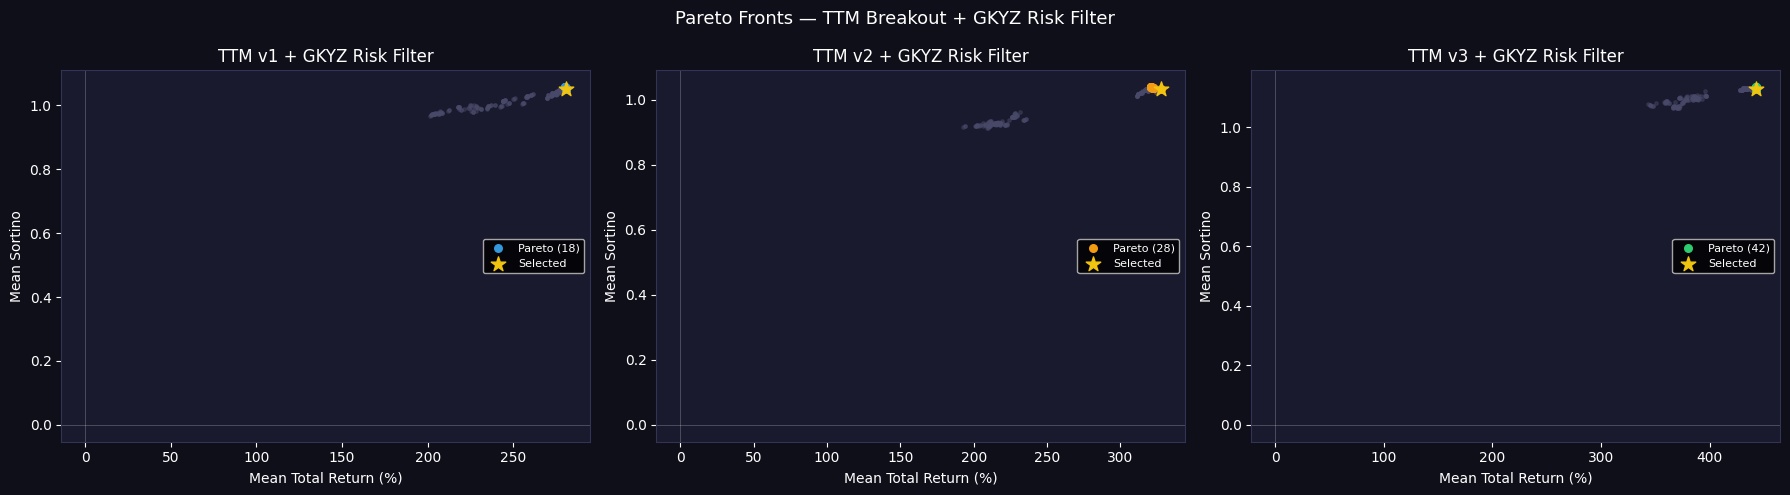

In [11]:
COLORS = {'v1': '#3498db', 'v2': '#f39c12', 'v3': '#2ecc71'}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.patch.set_facecolor('#0f0f1a')

for ax, ver in zip(axes, ['v1', 'v2', 'v3']):
    study = studies_gkyz[ver]
    col   = COLORS[ver]
    ax.set_facecolor('#1a1a2e')
    all_v = [(t.values[0], t.values[1]) for t in study.trials
             if t.values and t.values[0] != -999.0]
    pf_v  = [(t.values[0], t.values[1]) for t in study.best_trials]
    ax.scatter([v[0] for v in all_v], [v[1] for v in all_v],
               color='#4a4a6a', s=6, alpha=0.4)
    ax.scatter([v[0] for v in pf_v],  [v[1] for v in pf_v],
               color=col, s=30, zorder=5, label=f'Pareto ({len(pf_v)})')
    bx, by = best_trials_gkyz[ver].values
    ax.scatter([bx], [by], color='#f1c40f', s=120, marker='*', zorder=6, label='Selected')
    ax.axvline(0, color='white', lw=0.5, alpha=0.3)
    ax.axhline(0, color='white', lw=0.5, alpha=0.3)
    ax.set_title(f'TTM {ver} + GKYZ Risk Filter', color='white')
    ax.set_xlabel('Mean Total Return (%)', color='white')
    ax.set_ylabel('Mean Sortino', color='white')
    ax.tick_params(colors='white')
    ax.legend(fontsize=8)
    for sp in ax.spines.values(): sp.set_edgecolor('#333355')

plt.suptitle('Pareto Fronts — TTM Breakout + GKYZ Risk Filter', color='white', fontsize=13)
plt.tight_layout()
plt.show()

## 9. Final Backtest — Optimised v1 / v2 / v3 + GKYZ Risk Filter

In [12]:
portfolios_gkyz = {}
portfolios_ttm  = {}

for ver in ['v1', 'v2', 'v3']:
    p = best_params_gkyz[ver]

    entries = compute_signals(
        close, high, low,
        bb_window=p['bb_window'], bb_multiplier=p['bb_multiplier'],
        bb_matype=p.get('bb_matype', 0),
        kc_window=p['kc_window'], kc_multiplier=p['kc_multiplier'],
        kc_atr_period=p['kc_atr_period'],
        donichan_window=p['donichan_window'],
        osc_smoothing_period=p['osc_smoothing_period'],
        entry_version=ver,
        consecutive_neg_threshold=p.get('consecutive_neg_threshold', 7),
        william_vix_period=p.get('william_vix_period', 20),
        use_kama_slope=True,
        kama_period=p.get('kama_period', 10),
        kama_fast=p.get('kama_fast', 2),
        kama_slow=p.get('kama_slow', 30),
        kama_slope_win=p.get('kama_slope_win', 5),
        flat_threshold_pct=p.get('flat_threshold_pct', 1.0),
    )
    exits, sl_stop_df = compute_exits(
        close, high, low,
        atr_multiplier=p['atr_multiplier'],
        atr_period=p.get('atr_period', 10),
        low_stop_lookback=p.get('low_stop_lookback', 5),
    )

    # ── TTM-only (no filter) ─────────────────────────────────────────────────
    print(f'Running optimised {ver} (TTM, no filter) ...')
    pf_ttm = vbt.Portfolio.from_signals(
        close=close, entries=entries, exits=exits, sl_stop=sl_stop_df,
        freq='1d', group_by=['symbol'], cash_sharing=False,
    )
    portfolios_ttm[ver] = pf_ttm

    # ── TTM + GKYZ risk filter ───────────────────────────────────────────────
    print(f'Running optimised {ver} + GKYZ risk filter ...')
    _, ron = compute_gkyz_regime(
        open_['VNINDEX'], high['VNINDEX'], low['VNINDEX'], close['VNINDEX'],
        window=int(p['gkyz_window']),
        upper=float(p['gkyz_upper']),
        lower=float(p['gkyz_lower']),
    )
    sizing = GKYZ_SIZE_MR if ver == 'v3' else GKYZ_SIZE_TREND
    size_mat = build_size_matrix(ron, close.columns, **sizing)

    pf_gkyz = vbt.Portfolio.from_signals(
        close=close, entries=entries, exits=exits, sl_stop=sl_stop_df,
        size=size_mat, size_type='percent',
        freq='1d', group_by=['symbol'], cash_sharing=False,
    )
    portfolios_gkyz[ver] = pf_gkyz

    print(f'  TTM  trades={int(pf_ttm.trades.count().sum()):,}')
    print(f'  GKYZ trades={int(pf_gkyz.trades.count().sum()):,}')

print('\nAll done.')

Running optimised v1 (TTM, no filter) ...
Running optimised v1 + GKYZ risk filter ...
  TTM  trades=11,894
  GKYZ trades=11,894
Running optimised v2 (TTM, no filter) ...
Running optimised v2 + GKYZ risk filter ...
  TTM  trades=10,514
  GKYZ trades=10,514
Running optimised v3 (TTM, no filter) ...
Running optimised v3 + GKYZ risk filter ...
  TTM  trades=11,170
  GKYZ trades=11,170

All done.


## 10. Comparison — Stats Table

In [13]:
def version_stats(label, pf):
    s   = pf.sharpe_ratio().replace([np.inf, -np.inf], np.nan).dropna()
    so  = pf.sortino_ratio().replace([np.inf, -np.inf], np.nan).dropna()
    cm  = pf.calmar_ratio().replace([np.inf, -np.inf], np.nan).dropna()
    tr  = pf.total_return().replace([np.inf, -np.inf], np.nan).dropna()
    mdd = pf.max_drawdown().replace([np.inf, -np.inf], np.nan).dropna()
    wr  = pf.trades.win_rate().replace([np.inf, -np.inf], np.nan).dropna()
    return {
        'Strategy':       label,
        'Sharpe mean':    round(s.mean(),   3),
        'Sharpe median':  round(s.median(), 3),
        'Sharpe > 0':     f'{(s > 0).sum()}/{len(s)}',
        'Sharpe > 1':     f'{(s > 1).sum()}/{len(s)}',
        'Sortino mean':   round(so.mean(),  3),
        'Calmar mean':    round(cm.mean(),  3),
        'Total Ret mean': f'{tr.mean()*100:.1f}%',
        'Max DD mean':    f'{mdd.mean()*100:.1f}%',
        'Win Rate mean':  f'{wr.mean()*100:.1f}%',
        'Trades median':  int(pf.trades.count().median()),
    }

rows = [
    version_stats('Baseline (no filter)',     pf_base),
    version_stats('Baseline + GKYZ filter',   pf_base_gkyz),
    *[version_stats(f'Opt {v} (TTM)',         portfolios_ttm[v])  for v in ['v1','v2','v3']],
    *[version_stats(f'Opt {v} + GKYZ',        portfolios_gkyz[v]) for v in ['v1','v2','v3']],
]
stats_df = pd.DataFrame(rows).set_index('Strategy').T
stats_df

Strategy,Baseline (no filter),Baseline + GKYZ filter,Opt v1 (TTM),Opt v2 (TTM),Opt v3 (TTM),Opt v1 + GKYZ,Opt v2 + GKYZ,Opt v3 + GKYZ
Sharpe mean,0.588,0.587,0.706,0.681,0.693,0.665,0.654,0.724
Sharpe median,0.577,0.578,0.728,0.694,0.695,0.692,0.657,0.742
Sharpe > 0,191/197,186/197,191/197,189/197,191/197,191/197,185/197,190/197
Sharpe > 1,26/197,26/197,35/197,42/197,36/197,33/197,43/197,44/197
Sortino mean,0.917,0.921,1.114,1.073,1.073,1.05,1.033,1.129
Calmar mean,0.371,0.368,0.504,0.505,0.468,0.464,0.487,0.502
Total Ret mean,222.5%,187.6%,455.4%,491.8%,486.7%,280.8%,327.6%,442.8%
Max DD mean,-45.6%,-41.8%,-46.7%,-45.4%,-51.2%,-39.8%,-39.9%,-46.6%
Win Rate mean,39.6%,39.6%,40.8%,33.4%,38.7%,40.8%,33.4%,38.7%
Trades median,57,57,61,56,58,61,56,58


## 11. Sharpe Distribution — GKYZ Filter vs No Filter

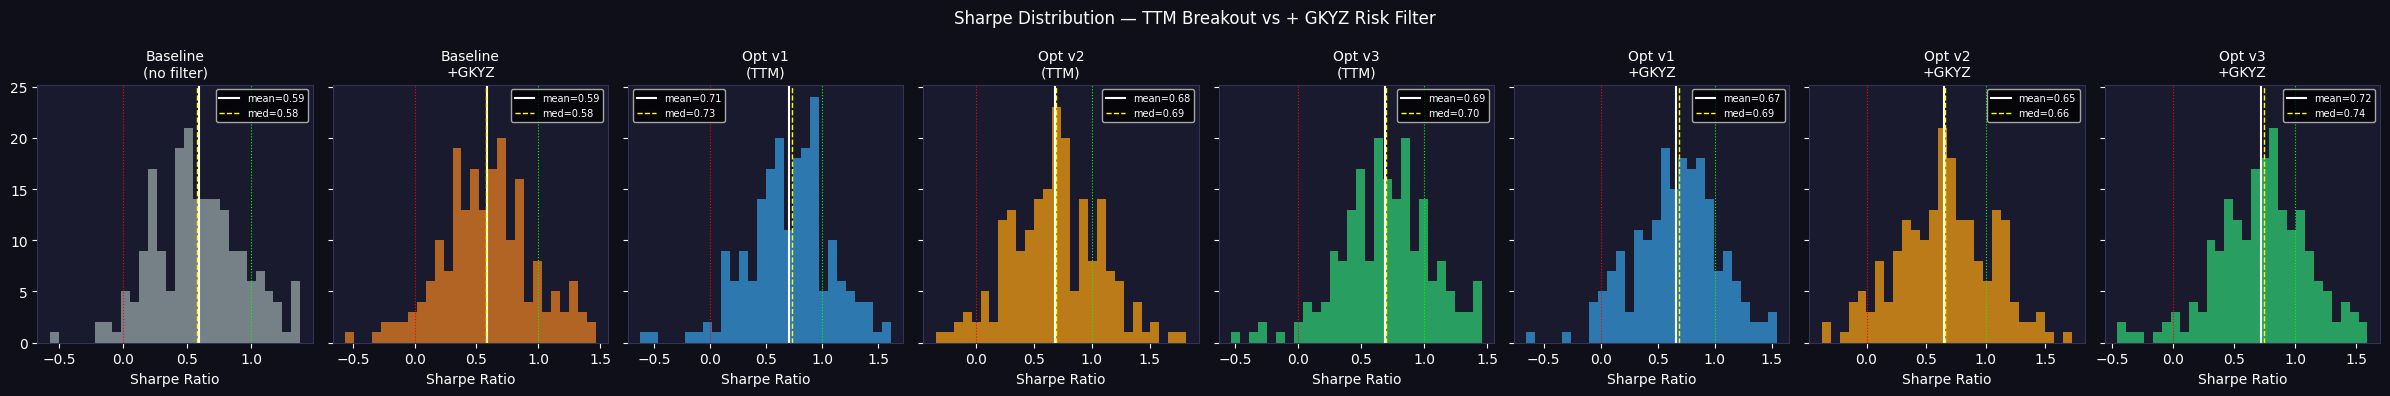

In [14]:
COLORS = {'v1': '#3498db', 'v2': '#f39c12', 'v3': '#2ecc71'}

entries_list = [
    ('Baseline\n(no filter)', pf_base,      '#95a5a6'),
    ('Baseline\n+GKYZ',       pf_base_gkyz, '#e67e22'),
    *[(f'Opt {v}\n(TTM)',  portfolios_ttm[v],  COLORS[v]) for v in ['v1','v2','v3']],
    *[(f'Opt {v}\n+GKYZ', portfolios_gkyz[v], COLORS[v]) for v in ['v1','v2','v3']],
]

n = len(entries_list)
fig, axes = plt.subplots(1, n, figsize=(max(22, 3.0 * n), 4), sharey=True)
fig.patch.set_facecolor('#0f0f1a')

for ax, (name, pf, col) in zip(axes, entries_list):
    sv = pf.sharpe_ratio().replace([np.inf, -np.inf], np.nan).dropna()
    ax.set_facecolor('#1a1a2e')
    ax.hist(sv, bins=28, color=col, alpha=0.75, edgecolor='none')
    ax.axvline(sv.mean(),   color='white',  lw=1.5, ls='-',  label=f'mean={sv.mean():.2f}')
    ax.axvline(sv.median(), color='yellow', lw=1.0, ls='--', label=f'med={sv.median():.2f}')
    ax.axvline(0, color='red',  lw=0.8, ls=':')
    ax.axvline(1, color='lime', lw=0.8, ls=':')
    ax.set_title(name, color='white', fontsize=10)
    ax.set_xlabel('Sharpe Ratio', color='white')
    ax.tick_params(colors='white')
    ax.legend(fontsize=7)
    for sp in ax.spines.values(): sp.set_edgecolor('#333355')

plt.suptitle('Sharpe Distribution — TTM Breakout vs + GKYZ Risk Filter', color='white', fontsize=12)
plt.tight_layout()
plt.show()

## 12. Delta Sharpe vs Baseline (No Filter)

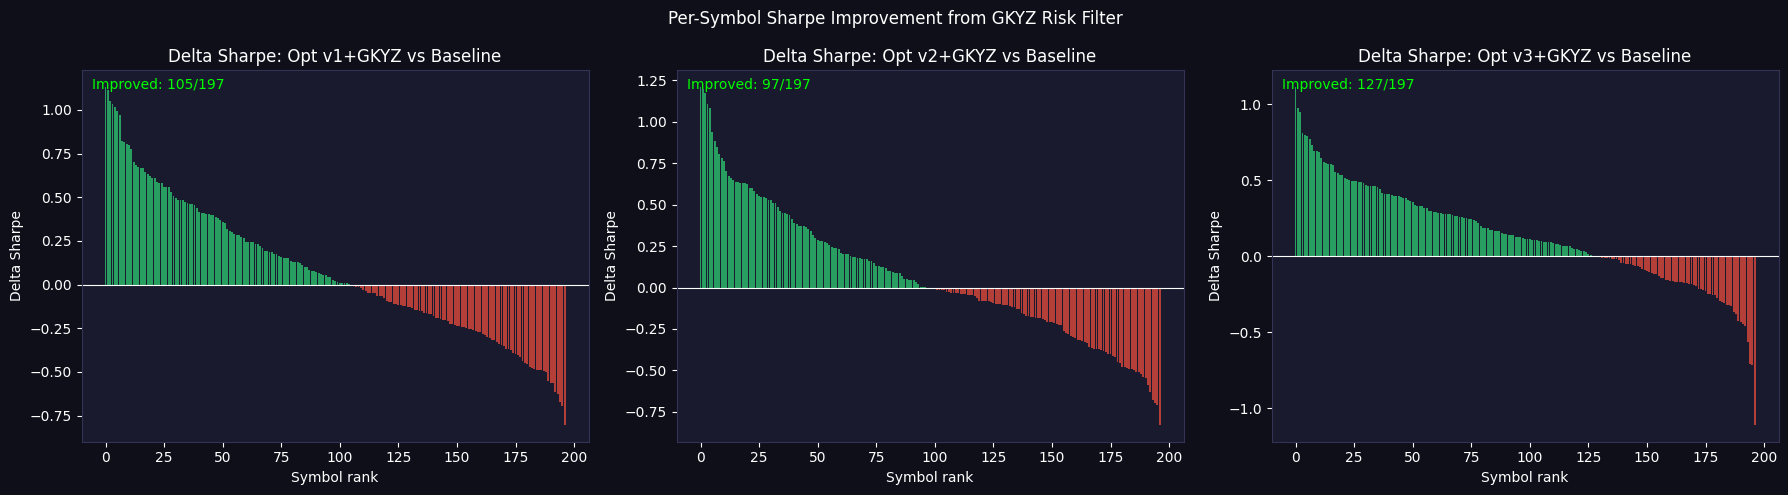

In [15]:
COLORS = {'v1': '#3498db', 'v2': '#f39c12', 'v3': '#2ecc71'}
sr_base = pf_base.sharpe_ratio().replace([np.inf, -np.inf], np.nan)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.patch.set_facecolor('#0f0f1a')

for ax, ver in zip(axes, ['v1', 'v2', 'v3']):
    pf     = portfolios_gkyz[ver]
    sr_opt = pf.sharpe_ratio().replace([np.inf, -np.inf], np.nan)
    delta  = (sr_opt - sr_base).dropna().sort_values(ascending=False)
    colors = ['#2ecc71' if v >= 0 else '#e74c3c' for v in delta]
    ax.set_facecolor('#1a1a2e')
    ax.bar(range(len(delta)), delta.values, color=colors, alpha=0.75)
    ax.axhline(0, color='white', lw=0.8)
    ax.set_title(f'Delta Sharpe: Opt {ver}+GKYZ vs Baseline', color='white')
    ax.set_xlabel('Symbol rank', color='white')
    ax.set_ylabel('Delta Sharpe', color='white')
    ax.tick_params(colors='white')
    improved = (delta > 0).sum()
    ax.text(0.02, 0.95, f'Improved: {improved}/{len(delta)}',
            transform=ax.transAxes, color='lime', fontsize=10)
    for sp in ax.spines.values(): sp.set_edgecolor('#333355')

plt.suptitle('Per-Symbol Sharpe Improvement from GKYZ Risk Filter', color='white', fontsize=12)
plt.tight_layout()
plt.show()

## 13. Single-Symbol — TTM Entries with GKYZ Regime Overlay

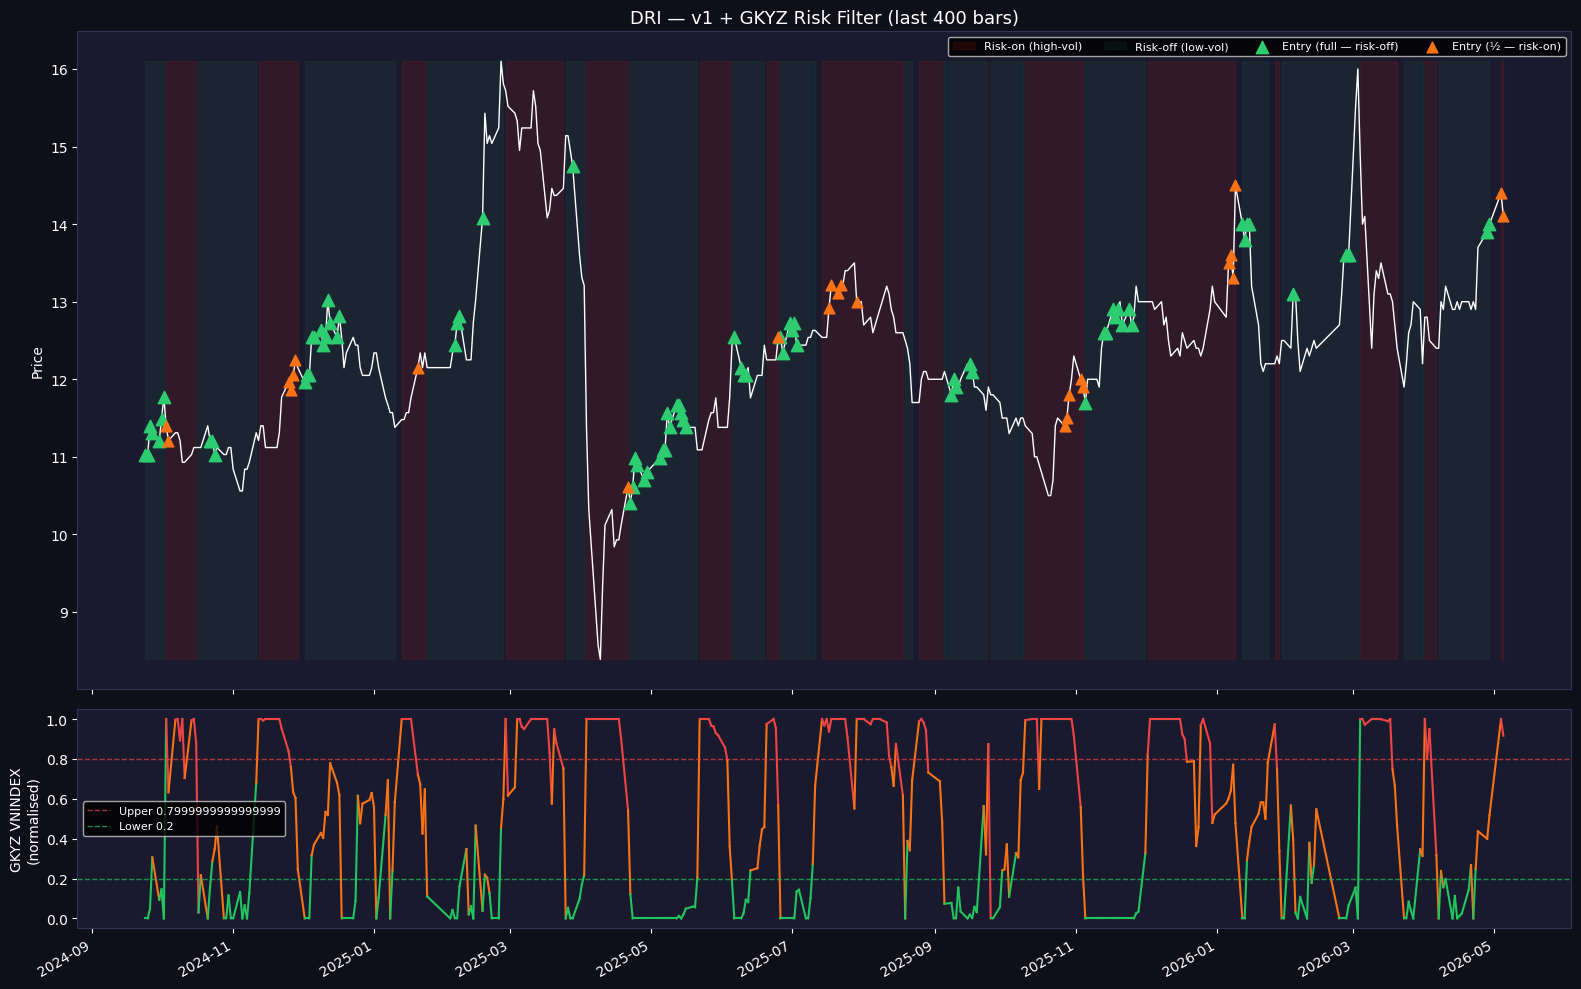

DRI | Sharpe: 0.905  Total Ret: 418.9%


In [ ]:
VER          = 'v1'
SYMBOL       = 'DRI'
LOOKBACK_DAYS = 400

GKYZ_WINDOW = 20
GKYZ_UPPER  = 0.8
GKYZ_LOWER  = 0.2

p = best_params_gkyz[VER]
_, ron_sym = compute_gkyz_regime(
    open_['VNINDEX'], high['VNINDEX'], low['VNINDEX'], close['VNINDEX'],
    window=GKYZ_WINDOW, upper=GKYZ_UPPER, lower=GKYZ_LOWER,
)
gkyz_sym, _ = compute_gkyz_regime(
    open_['VNINDEX'], high['VNINDEX'], low['VNINDEX'], close['VNINDEX'],
    window=GKYZ_WINDOW, upper=GKYZ_UPPER, lower=GKYZ_LOWER,
)

ttm_entries_raw = compute_signals(
    close, high, low,
    bb_window=p['bb_window'], bb_multiplier=p['bb_multiplier'],
    bb_matype=p.get('bb_matype', 0),
    kc_window=p['kc_window'], kc_multiplier=p['kc_multiplier'],
    kc_atr_period=p['kc_atr_period'],
    donichan_window=p['donichan_window'], osc_smoothing_period=p['osc_smoothing_period'],
    entry_version=VER,
    consecutive_neg_threshold=p.get('consecutive_neg_threshold', 7),
    william_vix_period=p.get('william_vix_period', 20),
    use_kama_slope=True,
    kama_period=p.get('kama_period', 10), kama_fast=p.get('kama_fast', 2),
    kama_slow=p.get('kama_slow', 30), kama_slope_win=p.get('kama_slope_win', 5),
    flat_threshold_pct=p.get('flat_threshold_pct', 1.0),
)

c_sym   = close[SYMBOL].values
dates   = close.index
n_show  = min(LOOKBACK_DAYS, len(dates))
sl_     = slice(-n_show, None)
dates_s = dates[sl_]

ttm_raw   = ttm_entries_raw[SYMBOL].values.astype(bool)[sl_]
ron_arr   = ron_sym.values[sl_]
# Position scale: v1/v2 trend (½ risk-on) vs v3 MR (full risk-on)
if VER == 'v3':
    entry_full = ttm_raw &  ron_arr
    entry_half = ttm_raw & ~ron_arr
else:
    entry_full = ttm_raw & ~ron_arr
    entry_half = ttm_raw &  ron_arr

fig, axes = plt.subplots(2, 1, figsize=(16, 10), sharex=True,
                          gridspec_kw={'height_ratios': [3, 1]})
fig.patch.set_facecolor('#0f0f1a')

ax = axes[0]
ax.set_facecolor('#1a1a2e')
c_s = c_sym[sl_]
ax.fill_between(dates_s, c_s.min(), c_s.max(),
                where=ron_arr,  color='#f71c05', alpha=0.10, label='Risk-on (high-vol)')
ax.fill_between(dates_s, c_s.min(), c_s.max(),
                where=~ron_arr, color='#2ecc71', alpha=0.06, label='Risk-off (low-vol)')
ax.plot(dates_s, c_s, color='white', lw=1.0)
ax.scatter(dates_s[entry_full], c_s[entry_full],
           marker='^', color='#2ecc71', s=80, zorder=5,
           label=('Entry (full — risk-on)' if VER == 'v3' else 'Entry (full — risk-off)'))
ax.scatter(dates_s[entry_half], c_s[entry_half],
           marker='^', color='#f97316', s=60, zorder=5,
           label=('Entry (½ — risk-off)' if VER == 'v3' else 'Entry (½ — risk-on)'))
ax.set_title(f'{SYMBOL} — {VER} + GKYZ Risk Filter (last {n_show} bars)', color='white', fontsize=13)
ax.set_ylabel('Price', color='white')
ax.legend(fontsize=8, ncol=4)
ax.tick_params(colors='white')
for sp in ax.spines.values(): sp.set_edgecolor('#333355')

ax2 = axes[1]
ax2.set_facecolor('#1a1a2e')
g_arr = gkyz_sym.values[sl_]
colors_g = np.where(g_arr > float(p['gkyz_upper']), '#ef4444',
           np.where(g_arr < float(p['gkyz_lower']), '#22c55e', '#f97316'))
for i in range(len(dates_s) - 1):
    ax2.plot(dates_s[i:i+2], g_arr[i:i+2], color=colors_g[i], lw=1.5)
ax2.axhline(float(p['gkyz_upper']), color='#ef4444', lw=1.0, ls='--', alpha=0.7,
            label=f"Upper {p['gkyz_upper']}")
ax2.axhline(float(p['gkyz_lower']), color='#22c55e', lw=1.0, ls='--', alpha=0.7,
            label=f"Lower {p['gkyz_lower']}")
ax2.set_ylim(-0.05, 1.05)
ax2.set_ylabel('GKYZ VNINDEX\n(normalised)', color='white')
ax2.legend(fontsize=8)
ax2.tick_params(colors='white')
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
fig.autofmt_xdate(rotation=30)
for sp in ax2.spines.values(): sp.set_edgecolor('#333355')

plt.tight_layout()
plt.show()

pf_sym = portfolios_gkyz[VER]
print(f'{SYMBOL} | Sharpe: {pf_sym.sharpe_ratio()[SYMBOL]:.3f}  Total Ret: {pf_sym.total_return()[SYMBOL]*100:.1f}%')